<a href="https://colab.research.google.com/github/keshavTUM/DEMO_BuildingClassification/blob/main/Working_Multi_FULLimageRetrieval_With_Part%2BFull_embedeggings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Automated Dataset Generation with Grounding DINO + Segment Anything Model (SAM)

---

In this tutorial, you will learn how to automatically annotate your images using two groundbreaking models - [Grounding DINO](https://github.com/IDEA-Research/GroundingDINO) and [Segment Anything Model (SAM)](https://github.com/facebookresearch/segment-anything). You can then use this dataset to train a real-time object detection or instance segmentation model. Annotation of images using polygons in the traditional way is extremely time-consuming and expensive. With Grounding DINO and SAM, initial annotation takes only a few minutes and your work is reduced to manual verification of obtained labels.

![auto-annotation-with-grounded-sam](https://media.roboflow.com/notebooks/examples/auto-annotation-with-grounded-sam.png)

*Figure showing the effects of automatic annotation. The raw image on the left; Object detection annotations obtained with Grounding DINO in the middle; Instance segmentation annotations obtained with Grounding DINO + SAM on the right.*

## Complementary Materials

---

Want to learn more? 🤓 We have prepared separate tutorials where you can learn how to use Grounding DINO and Segment Anything Model (SAM). You will find all the necessary links below.

- Segment Anything Model

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/facebookresearch/segment-anything) [![arXiv](https://img.shields.io/badge/arXiv-2304.02643-b31b1b.svg)](https://arxiv.org/abs/2304.02643) [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-segment-anything-with-sam.ipynb) [![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/D-D6ZmadzPE) [![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-use-segment-anything-model-sam)

- Grounding DINO

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/IDEA-Research/GroundingDINO) [![arXiv](https://img.shields.io/badge/arXiv-2303.05499-b31b1b.svg)](https://arxiv.org/abs/2303.05499) [![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/zero-shot-object-detection-with-grounding-dino.ipynb) [![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/cMa77r3YrDk) [![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/grounding-dino-zero-shot-object-detection)

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- Before you start
- Install Grounding DINO and Segment Anything Model
- Load models
- Download Example Data
- Single Image Mask Auto Annotation
- Full Dataset Mask Auto Annotation
- Convert Object Detection to Instance Segmentation Dataset

## Let's begin! 🔥

## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
# Check current PyTorch version
import torch
print(torch.__version__)


2.6.0+cu124


In [2]:
!pip uninstall torch torchvision torchaudio -y

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124


In [3]:
!pip install torch==2.5.1
!pip install torchvision==0.20.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.5/906.5 MB 786.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 5.6 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 102.4 MB/s eta 0:00:00


In [4]:
import sdfhdsjk  #restart runtime

ModuleNotFoundError: No module named 'sdfhdsjk'

In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
# Check current PyTorch version
import torch
print(torch.__version__)


2.5.1+cu124


In [3]:
!nvidia-smi

Thu May 29 21:12:32 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [4]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


## Install Grounding DINO and Segment Anything Model

Our project will use two groundbreaking designs - [Grounding DINO](https://github.com/IDEA-Research/GroundingDINO) - for zero-shot detection and [Segment Anything Model (SAM)](https://github.com/facebookresearch/segment-anything) - for converting boxes into segmentations. We have to install them first.


In [5]:
# prompt: delete this folder if already exist  %cd {HOME}/GroundingDINO

import os
import shutil

HOME = os.getcwd()
grounding_dino_path = os.path.join(HOME, "GroundingDINO")

if os.path.exists(grounding_dino_path):
  shutil.rmtree(grounding_dino_path)
  print(f"Folder '{grounding_dino_path}' deleted successfully.")
else:
  print(f"Folder '{grounding_dino_path}' does not exist.")


Folder '/content/GroundingDINO' does not exist.


In [6]:
%cd {HOME}
!git clone https://github.com/IDEA-Research/GroundingDINO.git
%cd {HOME}/GroundingDINO
!git checkout -q 57535c5a79791cb76e36fdb64975271354f10251
!pip install -q -e .

/content
Cloning into 'GroundingDINO'...
remote: Enumerating objects: 463, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 463 (delta 175), reused 136 (delta 136), pack-reused 223 (from 1)
Receiving objects: 100% (463/463), 12.87 MiB | 17.23 MiB/s, done.
Resolving deltas: 100% (241/241), done.
/content/GroundingDINO
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 17.2 MB/s eta 0:00:00


In [7]:
%cd {HOME}

import sys
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

/content
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-sva4h767
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-sva4h767
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=c02b1ba98defc51c29f6ed0248cb273618d98985af121f84edfdbee7cc25d71a
  Stored in directory: /tmp/pip-ephem-wheel-cache-o4pf7m6x/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything


**NOTE:** To glue all the elements of our demo together we will use the [`supervision`](https://github.com/roboflow/supervision) pip package, which will help us **process, filter and visualize our detections as well as to save our dataset**. A lower version of the `supervision` was installed with Grounding DINO. However, in this demo we need the functionality introduced in the latest versions. Therefore, we uninstall the current `supervsion` version and install version `0.6.0`.



In [8]:
!pip uninstall -y supervision
!pip install -q supervision==0.6.0

import supervision as sv
print(sv.__version__)

Found existing installation: supervision 0.4.0
Uninstalling supervision-0.4.0:
  Successfully uninstalled supervision-0.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
groundingdino 0.1.0 requires supervision==0.4.0, but you have supervision 0.6.0 which is incompatible.
0.6.0


**NOTE:** At the end of the tutorial we will upload our annotations to [Roboflow](roboflow.com). To automate this process with the API, let's install the `roboflow` pip package.

In [9]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
groundingdino 0.1.0 requires supervision==0.4.0, but you have supervision 0.6.0 which is incompatible.


### Download Grounding DINO Model Weights

To run Grounding DINO we need two files - configuration and model weights. The configuration file is part of the [Grounding DINO](https://github.com/IDEA-Research/GroundingDINO) repository, which we have already cloned. The weights file, on the other hand, we need to download. We write the paths to both files to the `GROUNDING_DINO_CONFIG_PATH` and `GROUNDING_DINO_CHECKPOINT_PATH` variables and verify if the paths are correct and the files exist on disk.

In [10]:
import os

GROUNDING_DINO_CONFIG_PATH = os.path.join(HOME, "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py")
print(GROUNDING_DINO_CONFIG_PATH, "; exist:", os.path.isfile(GROUNDING_DINO_CONFIG_PATH))

/content/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py ; exist: True


In [11]:
%cd {HOME}
!mkdir -p {HOME}/weights
%cd {HOME}/weights

!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth

/content
/content/weights


In [12]:
import os

GROUNDING_DINO_CHECKPOINT_PATH = os.path.join(HOME, "weights", "groundingdino_swint_ogc.pth")
print(GROUNDING_DINO_CHECKPOINT_PATH, "; exist:", os.path.isfile(GROUNDING_DINO_CHECKPOINT_PATH))

/content/weights/groundingdino_swint_ogc.pth ; exist: True


### Download Segment Anything Model (SAM) Weights

As with Grounding DINO, in order to run SAM we need a weights file, which we must first download. We write the path to local weight file to `SAM_CHECKPOINT_PATH` variable and verify if the path is correct and the file exist on disk.

In [13]:
%cd {HOME}
!mkdir -p {HOME}/weights
%cd {HOME}/weights

!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

/content
/content/weights


In [14]:
import os

SAM_CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(SAM_CHECKPOINT_PATH, "; exist:", os.path.isfile(SAM_CHECKPOINT_PATH))

/content/weights/sam_vit_h_4b8939.pth ; exist: True


## Load models

In [15]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Load Grounding DINO Model

In [16]:
%cd {HOME}/GroundingDINO

from groundingdino.util.inference import Model

grounding_dino_model = Model(model_config_path=GROUNDING_DINO_CONFIG_PATH, model_checkpoint_path=GROUNDING_DINO_CHECKPOINT_PATH)

/content/GroundingDINO


/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

/content/GroundingDINO/groundingdino/util/inference.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_checkpoint_path, map_location="cpu")


### Load Segment Anything Model (SAM)

In [17]:
%cd {HOME}/weights
!rm sam_vit_h_4b8939.pth # Delete the existing file
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth # Re-download the file

/content/weights


In [18]:
SAM_ENCODER_VERSION = "vit_h"

In [19]:
!ls -l {HOME}/weights/sam_vit_h_4b8939.pth # Check the file size

-rw-r--r-- 1 root root 2564550879 Apr  4  2023 /content/weights/sam_vit_h_4b8939.pth


In [20]:
from segment_anything import sam_model_registry, SamPredictor

sam = sam_model_registry[SAM_ENCODER_VERSION](checkpoint=SAM_CHECKPOINT_PATH).to(device=DEVICE)
sam_predictor = SamPredictor(sam)

/usr/local/lib/python3.11/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


## Download Example Data

Let's download few example images. Feel free to replace my images with yours. All you have to do is upload them to the `{HOME}/data` directory. If you're looking for data, take a peek at [Roboflow Universe](https://universe.roboflow.com/)! You're sure to find something interesting.

In [21]:
f"{HOME}/data"

'/content/data'

In [22]:
%cd {HOME}
!mkdir {HOME}/data
%cd {HOME}/data


!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg


/content
/content/data


## Single Image Mask Auto Annotation

Before we automatically annotate the entire dataset let's focus for a moment on a single image.

In [23]:
SOURCE_IMAGE_PATH = f"{HOME}/data/dog-3.jpeg"
CLASSES = ['car', 'dog', 'person', 'nose', 'chair', 'shoe', 'ear']


In [24]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [25]:
SOURCE_IMAGE_PATH = f"{HOME}/drive/MyDrive/DATASETS/QueryPic/Pic/q4.jpg"
#/content/drive/MyDrive/DATASETS/QueryPic/Query.jpg


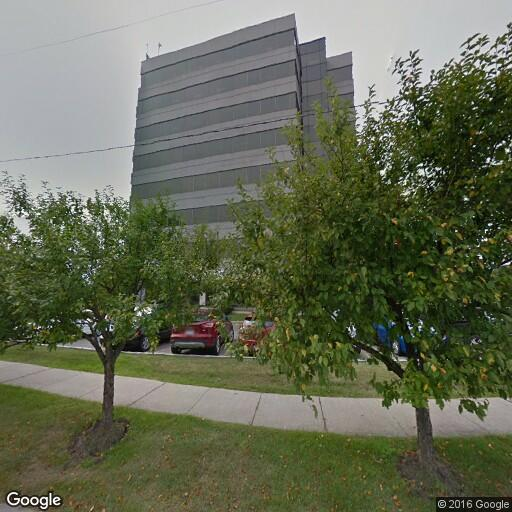

In [27]:
#prompt: dislay this image

from IPython.display import Image
Image(filename=SOURCE_IMAGE_PATH)


### Zero-Shot Object Detection with Grounding DINO

**NOTE:** To get better Grounding DINO detection we will leverage a bit of prompt engineering using `enhance_class_name` function defined below. 👇 You can learn more from our [Grounding DINO tutorial](https://blog.roboflow.com/grounding-dino-zero-shot-object-detection/).

Below code gives only only max IOU Bounding box

/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1613: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/content/GroundingDINO/groundingdino/models/GroundingDINO/transformer.py:862: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocas

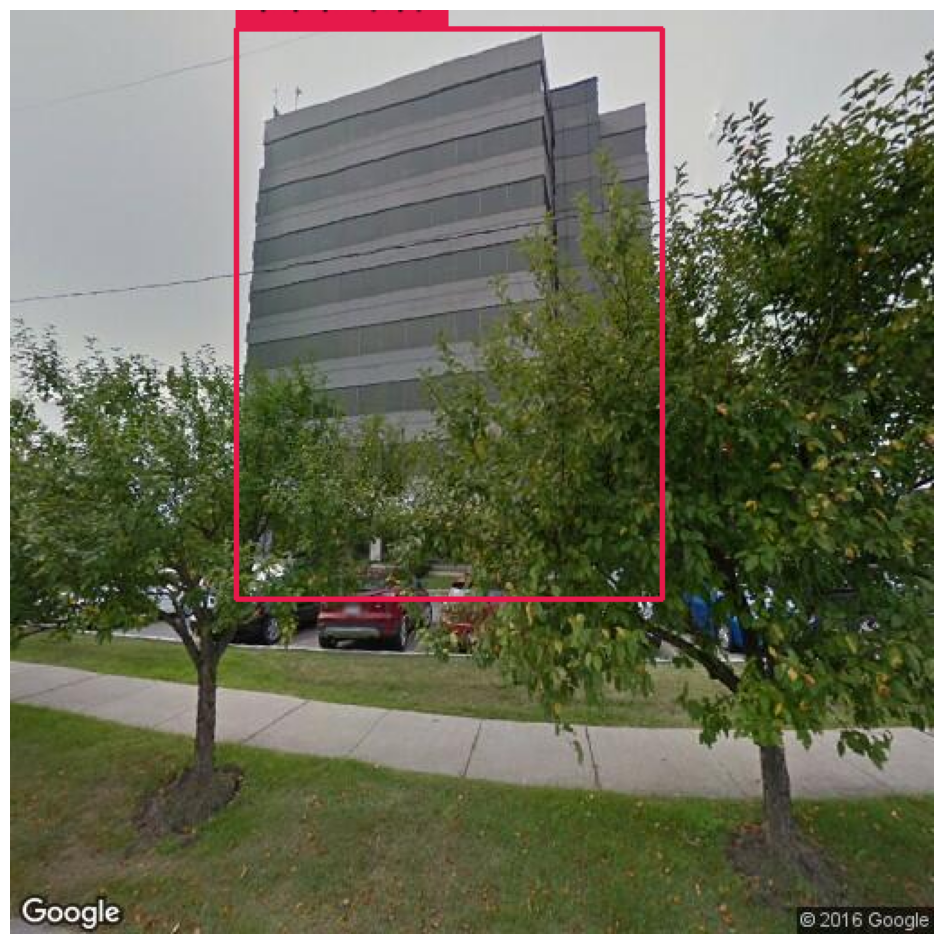

In [28]:
import cv2
import supervision as sv
import numpy as np
from typing import List

# === CONFIG ===
SOURCE_IMAGE_PATH = f"{HOME}/drive/MyDrive/DATASETS/QueryPic/Pic/q4.jpg"
#/content/drive/MyDrive/DATASETS/QueryPic/Query.jpg

BOX_THRESHOLD = 0.45
TEXT_THRESHOLD = 0.25
MIN_AREA = 10000  # Minimum box area in pixels to consider

# === DETECTION CLASSES ===
CLASSES = [
    "church", "facade", "walls", "windows", "doors", "arches", "columns", "cross",
    "steeple", "dome", "cornice", "roof", "bell tower", "entrance", "statue", "clock"
]
# === ENHANCE CLASS PROMPTS ===
def enhance_class_name(class_names: List[str]) -> List[str]:
    return [f"all {class_name}s" for class_name in class_names]

# === LOAD IMAGE ===
image = cv2.imread(SOURCE_IMAGE_PATH)
if image is None:
    raise ValueError(f"Failed to load image: {SOURCE_IMAGE_PATH}")

# === RUN GROUNDING DINO DETECTION ===
detections = grounding_dino_model.predict_with_classes(
    image=image,
    classes=enhance_class_name(class_names=CLASSES),
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD
)

# === HANDLE EMPTY DETECTIONS ===
if detections is None or len(detections.xyxy) == 0:
    print("No detections found.")
else:
    # === COMPUTE AREAS ===
    boxes = detections.xyxy
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

    # === FILTER BY MINIMUM AREA ===
    valid_idxs = np.where(areas > MIN_AREA)[0]
    if len(valid_idxs) == 0:
        print(f"No objects found larger than {MIN_AREA} pixels.")
    else:
        # === KEEP ONLY LARGEST VALID DETECTION ===
        largest_idx = valid_idxs[np.argmax(areas[valid_idxs])]
        # Apply filtering to xyxy, confidence, and class_id
        detections.xyxy = detections.xyxy[largest_idx:largest_idx+1]
        detections.confidence = [detections.confidence[largest_idx]]
        detections.class_id = [detections.class_id[largest_idx]]
        # Do NOT access or filter detections.mask here as it's not yet populated.

        # === ANNOTATE AND DISPLAY ===
        # Annotation and display should happen after segmentation if you want masks
        # This part currently only annotates the bounding box.
        box_annotator = sv.BoxAnnotator()
        labels = [
            f"{CLASSES[detections.class_id[0]]} {detections.confidence[0]:.2f}"
        ]
        annotated_frame = box_annotator.annotate(
            scene=image.copy(), detections=detections, labels=labels
        )

        # === DISPLAY RESULT ===
        %matplotlib inline
        sv.plot_image(annotated_frame, (12, 12))

# The segmentation step using SAM will follow this block, and will populate detections.mask
# and then you can proceed with mask annotation.

# part segmentation from a building parts in Example

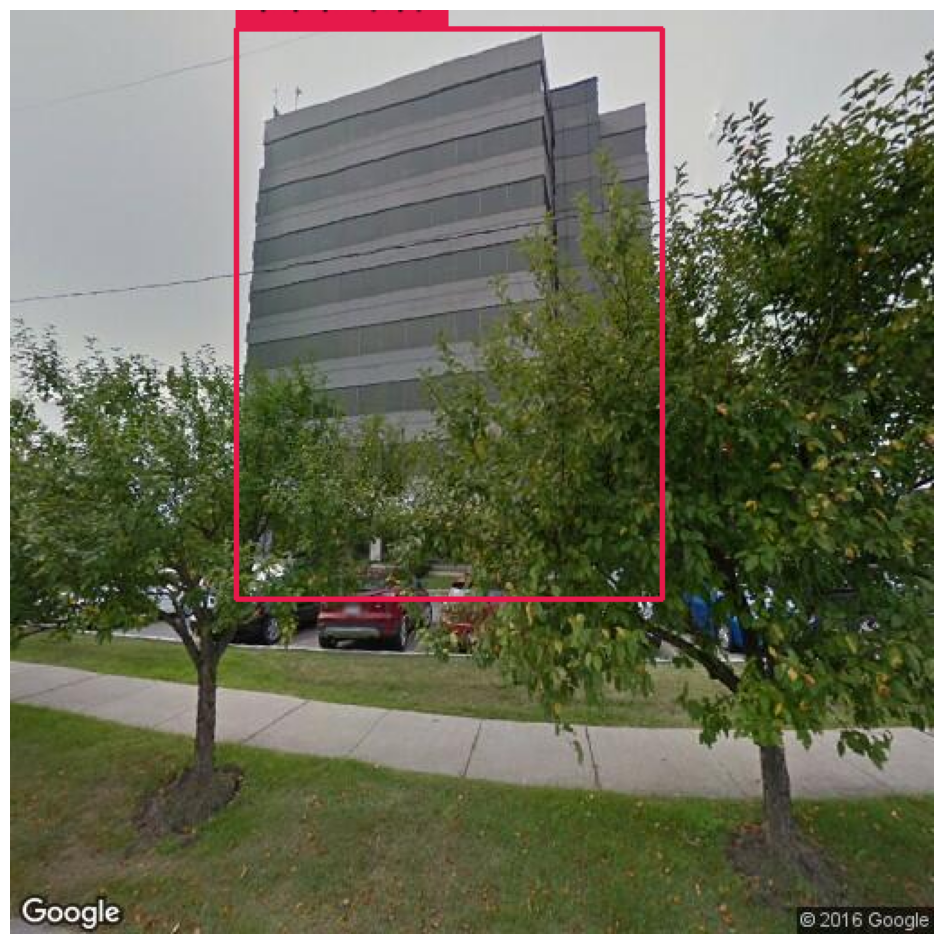

In [29]:
#in exmaple file, not in dataset

import cv2
import supervision as sv

# load image
image = cv2.imread(SOURCE_IMAGE_PATH)

#CLASSES = [ 'walls' , 'windows', 'facade', 'cornices', 'domb']
CLASSES = [
    "church", "facade", "walls", "windows", "doors", "arches", "columns", "cross",
    "steeple", "dome", "cornice", "roof", "bell tower", "entrance", "statue", "clock"
]

BOX_TRESHOLD = 0.45
TEXT_TRESHOLD = 0.25

from typing import List

def enhance_class_name(class_names: List[str]) -> List[str]:
    return [
        f"all {class_name}s"
        for class_name
        in class_names
    ]

# detect objects
detections = grounding_dino_model.predict_with_classes(
    image=image,
    classes=enhance_class_name(class_names=CLASSES),
    box_threshold=BOX_TRESHOLD,
    text_threshold=TEXT_TRESHOLD
)

# annotate image with detections
box_annotator = sv.BoxAnnotator()
labels = [
    f"{CLASSES[class_id]} {confidence:0.2f}"
    for _, _, confidence, class_id, _
    in detections]
annotated_frame = box_annotator.annotate(scene=image.copy(), detections=detections, labels=labels)

%matplotlib inline
sv.plot_image(annotated_frame, (12, 12))

### Prompting SAM with detected boxes

In [30]:
'''import cv2
import numpy as np
import supervision as sv
from typing import List

TARGET_CLASS = "church"  # <-- class you want to isolate
BOX_THRESHOLD = 0.45
TEXT_THRESHOLD = 0.25
MIN_AREA = 10000  # Minimum area in pixels

# === DETECTION CLASSES (for all relevant parts) ===
CLASSES = [
    "church", "facade", "walls", "windows", "doors", "arches", "columns", "cross",
    "steeple", "dome", "cornice", "roof", "bell tower", "entrance", "statue", "clock"
]

# === Enhance Prompt Format for GroundingDINO ===
def enhance_class_name(class_names: List[str]) -> List[str]:
    return [f"all {class_name}s" for class_name in class_names]

# === Load Image ===
image = cv2.imread(SOURCE_IMAGE_PATH)
if image is None:
    raise ValueError(f"Failed to load image: {SOURCE_IMAGE_PATH}")

# === Run GroundingDINO Detection ===
detections = grounding_dino_model.predict_with_classes(
    image=image,
    classes=enhance_class_name(class_names=CLASSES),
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD
)

if detections is None or len(detections.xyxy) == 0:
    print("No detections found.")
else:
    # === Filter Only Target Class (e.g., 'church') ===
    target_class_ids = [
        i for i, class_id in enumerate(detections.class_id)
        if CLASSES[class_id] == TARGET_CLASS
    ]

    if len(target_class_ids) == 0:
        print(f"No '{TARGET_CLASS}' found in detections.")
    else:
        # === Compute Area for Each Target Detection ===
        boxes = detections.xyxy[target_class_ids]
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

        # === Filter Based on Area Threshold ===
        valid_local_idxs = np.where(areas > MIN_AREA)[0]
        if len(valid_local_idxs) == 0:
            print(f"No '{TARGET_CLASS}' found above area {MIN_AREA}.")
        else:
            # === Get Global Index of the Largest Valid Target ===
            largest_local_idx = valid_local_idxs[np.argmax(areas[valid_local_idxs])]
            largest_global_idx = target_class_ids[largest_local_idx]

            # === Update detections to only keep this one ===
            detections.xyxy = detections.xyxy[largest_global_idx:largest_global_idx+1]
            detections.confidence = [detections.confidence[largest_global_idx]]
            detections.class_id = [detections.class_id[largest_global_idx]]
            # Remove the line below, as detections.mask is not populated yet
            # if hasattr(detections, "mask"):
            #     detections.mask = [detections.mask[largest_global_idx]]

            # === ANNOTATE AND DISPLAY ===
            # Annotation and display should happen after segmentation if you want masks
            # This part currently only annotates the bounding box.
            box_annotator = sv.BoxAnnotator()
            labels = [
                f"{TARGET_CLASS} {detections.confidence[0]:.2f}"
            ]
            annotated_frame = box_annotator.annotate(
                scene=image.copy(), detections=detections, labels=labels
            )

            # Display
            %matplotlib inline
            sv.plot_image(annotated_frame, (12, 12))

# The segmentation step using SAM will follow this block, and will populate detections.mask
# and then you can proceed with mask annotation.'''

'import cv2\nimport numpy as np\nimport supervision as sv\nfrom typing import List\n\nTARGET_CLASS = "church"  # <-- class you want to isolate\nBOX_THRESHOLD = 0.45\nTEXT_THRESHOLD = 0.25\nMIN_AREA = 10000  # Minimum area in pixels\n\n# === DETECTION CLASSES (for all relevant parts) ===\nCLASSES = [\n    "church", "facade", "walls", "windows", "doors", "arches", "columns", "cross",\n    "steeple", "dome", "cornice", "roof", "bell tower", "entrance", "statue", "clock"\n]\n\n# === Enhance Prompt Format for GroundingDINO ===\ndef enhance_class_name(class_names: List[str]) -> List[str]:\n    return [f"all {class_name}s" for class_name in class_names]\n\n# === Load Image ===\nimage = cv2.imread(SOURCE_IMAGE_PATH)\nif image is None:\n    raise ValueError(f"Failed to load image: {SOURCE_IMAGE_PATH}")\n\n# === Run GroundingDINO Detection ===\ndetections = grounding_dino_model.predict_with_classes(\n    image=image,\n    classes=enhance_class_name(class_names=CLASSES),\n    box_threshold=BOX_TH

In [31]:
import numpy as np
from segment_anything import SamPredictor


def segment(sam_predictor: SamPredictor, image: np.ndarray, xyxy: np.ndarray) -> np.ndarray:
    sam_predictor.set_image(image)
    result_masks = []
    for box in xyxy:
        masks, scores, logits = sam_predictor.predict(
            box=box,
            multimask_output=True
        )
        index = np.argmax(scores)
        result_masks.append(masks[index])
    return np.array(result_masks)

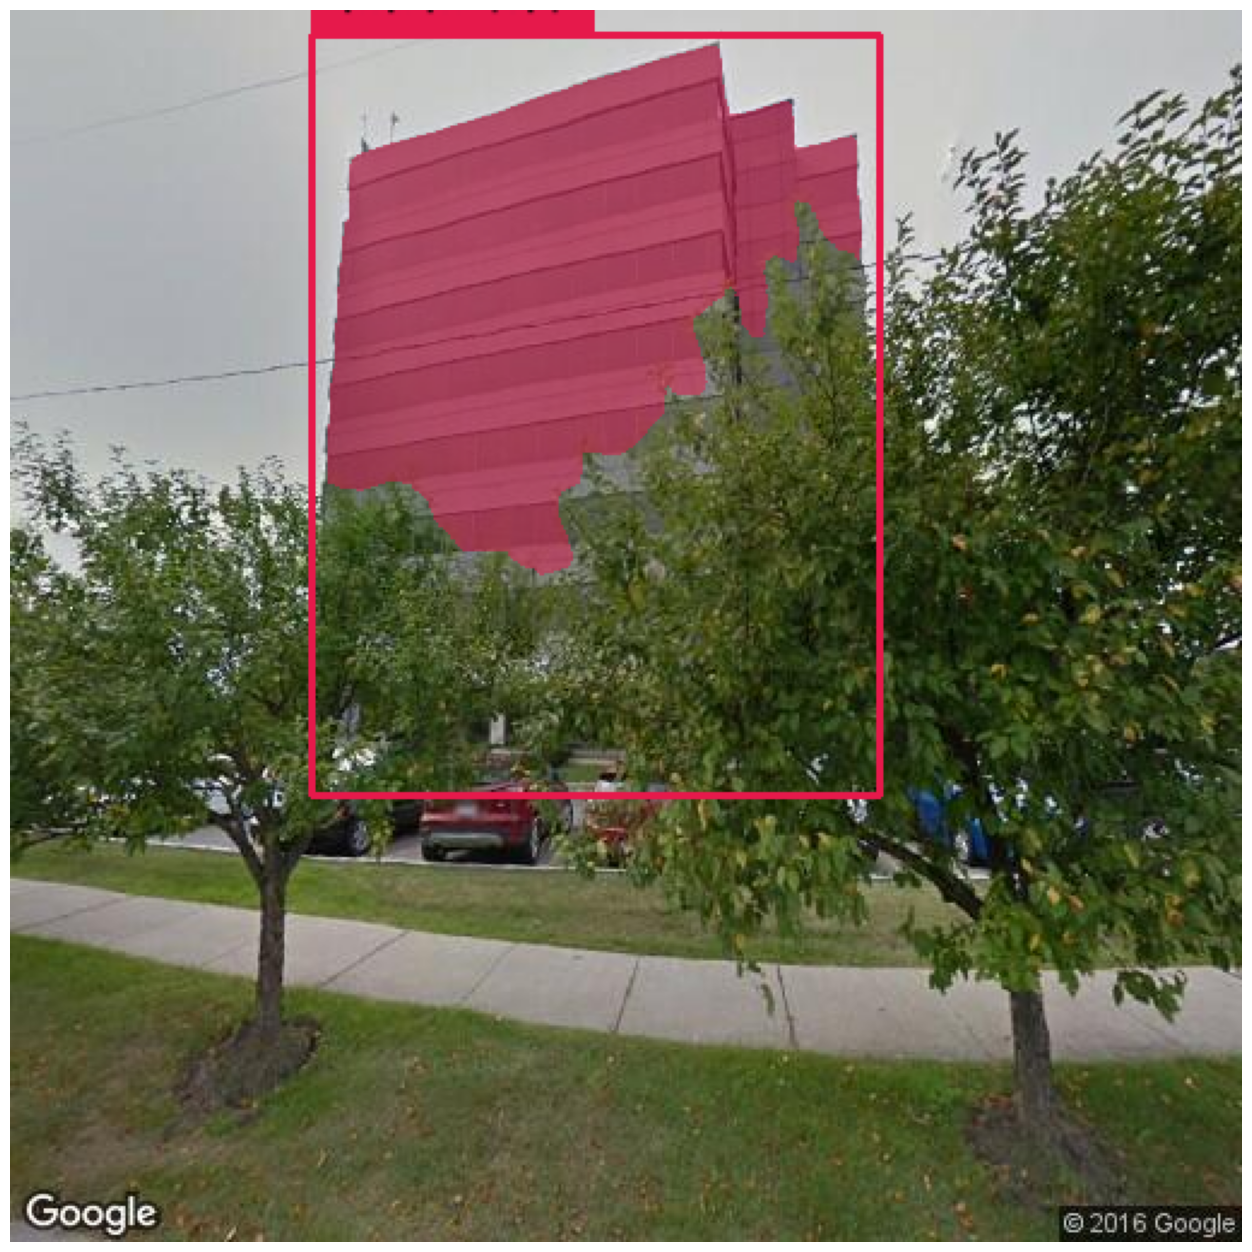

In [32]:
import cv2

# convert detections to masks
detections.mask = segment(
    sam_predictor=sam_predictor,
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    xyxy=detections.xyxy
)

# annotate image with detections
box_annotator = sv.BoxAnnotator()
mask_annotator = sv.MaskAnnotator()
labels = [
    f"{CLASSES[class_id]} {confidence:0.2f}"
    for _, _, confidence, class_id, _
    in detections]
annotated_image = mask_annotator.annotate(scene=image.copy(), detections=detections)
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

%matplotlib inline
sv.plot_image(annotated_image, (16, 16))

Full Dataset Mask Auto Annotation



In [33]:
import tobreakcode , if u want to create mask on all datset then run this below code or else for the query image mask, scroll down below

SyntaxError: invalid syntax (<ipython-input-33-781150c37758>, line 1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Final Annotated Image Generation Script (with proper structure + class folders)

 Convert All Images in Annotated_all to .jpeg

In [ ]:
import os
import cv2

IMAGES_DIRECTORY = '/content/drive/MyDrive/DATASETS/Building_labeled_train_data'
VALID_EXTS = ('.jpg', '.jpeg', '.png')

converted = 0

for root, _, files in os.walk(IMAGES_DIRECTORY):
    for file in files:
        if file.lower().endswith(VALID_EXTS):
            input_path = os.path.join(root, file)

            # Load image
            image = cv2.imread(input_path)
            if image is None:
                print(f"[SKIP] Failed to read: {input_path}")
                continue

            # Build new path with .jpeg extension
            new_name = os.path.splitext(file)[0] + '.jpeg'
            new_path = os.path.join(root, new_name)

            # Save as .jpeg and remove old file if different extension
            cv2.imwrite(new_path, image)
            if not file.lower().endswith('.jpeg'):
                os.remove(input_path)
                #print(f"✔ Converted: {file} -> {new_name}")
                converted += 1

print(f"\n✅ Done. Converted {converted} images to .jpeg format.")


In [ ]:
# === IMPORTS ===
import os
import cv2
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# === CONFIGURATION ===
IMAGES_DIRECTORY = '/content/drive/MyDrive/DATASETS/Building_labeled_train_data'
ANNOTATED_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'
CROP_DIR = '/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK'

CLASSES = ['building']
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25
MIN_AREA = 10000
BATCH_SIZE = 500
IMG_EXTENSIONS = ['jpg', 'jpeg', 'png']

# === SETUP DIRECTORIES ===
os.makedirs(ANNOTATED_DIR, exist_ok=True)
os.makedirs(CROP_DIR, exist_ok=True)

# === TRACKING ===
annotated_count = 0
skipped_images = []

# === Helper: Find image files ===
def list_image_files(root_dir, extensions):
    paths = []
    for root, _, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(tuple(extensions)):
                paths.append(os.path.join(root, file))
    return paths

# === Collect images ===
image_paths = list_image_files(IMAGES_DIRECTORY, IMG_EXTENSIONS)
print(f"Found {len(image_paths)} images.")

# === PROCESS IMAGES IN BATCHES ===
for batch_start in range(0, len(image_paths), BATCH_SIZE):
    batch_paths = image_paths[batch_start:batch_start + BATCH_SIZE]
    print(f"Processing batch {batch_start // BATCH_SIZE + 1}")

    for image_path in tqdm(batch_paths):
        image_name = os.path.basename(image_path)
        usage_type = os.path.basename(os.path.dirname(image_path))

        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"[ERROR] Cannot read: {image_path}")
            skipped_images.append(image_name)
            continue

        # Ensure class subfolder exists
        class_annot_dir = os.path.join(ANNOTATED_DIR, usage_type)
        class_crop_dir = os.path.join(CROP_DIR, usage_type)
        os.makedirs(class_annot_dir, exist_ok=True)
        os.makedirs(class_crop_dir, exist_ok=True)

        # Run detection
        detections = grounding_dino_model.predict_with_classes(
            image=image,
            classes=[f"all {cls}s" for cls in CLASSES],
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD
        )

        if detections is None or len(detections.xyxy) == 0:
            print(f"[SKIP] No detection for: {image_name}")
            skipped_images.append(image_name)
            continue

        # Filter largest box above area threshold
        boxes = detections.xyxy
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        valid_idxs = np.where(areas > MIN_AREA)[0]

        if len(valid_idxs) == 0:
            print(f"[SKIP] No large enough detection for: {image_name}")
            skipped_images.append(image_name)
            continue

        # Select largest detection
        largest_idx = valid_idxs[np.argmax(areas[valid_idxs])]
        detections.xyxy = detections.xyxy[largest_idx:largest_idx + 1]
        detections.confidence = [detections.confidence[largest_idx]]
        detections.class_id = [detections.class_id[largest_idx]]

        # Run SAM segmentation
        detections.mask = segment(
            sam_predictor=sam_predictor,
            image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
            xyxy=detections.xyxy
        )

        # Visualize
        box = detections.xyxy[0].astype(int)
        mask = detections.mask[0].astype(np.uint8) * 255

        # Annotate
        annotated_img = image.copy()
        cv2.rectangle(annotated_img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
        cv2.putText(annotated_img, f"{detections.confidence[0]:.2f}", (box[0], box[1] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        mask_colored = np.zeros_like(annotated_img, dtype=np.uint8)
        mask_colored[mask > 0] = (0, 255, 0)
        annotated_img = cv2.addWeighted(annotated_img, 0.6, mask_colored, 0.4, 0)

        # === Save annotated image ===
        annotated_path = os.path.join(class_annot_dir, image_name)
        cv2.imwrite(annotated_path, annotated_img)

        # === Save label CSV ===
        csv_path = os.path.join(class_annot_dir, image_name.replace('.jpg', '.csv').replace('.png', '.csv').replace('.jpeg', '.csv'))
        detections_df = pd.DataFrame([{
            'x_min': box[0],
            'y_min': box[1],
            'x_max': box[2],
            'y_max': box[3],
            'confidence': detections.confidence[0],
            'class_id': detections.class_id[0],
            'usage_type': usage_type
        }])
        detections_df.to_csv(csv_path, index=False)

        # === Crop and save the masked region ===
        masked = cv2.bitwise_and(image, image, mask=mask)
        cropped = masked[box[1]:box[3], box[0]:box[2]]
        crop_path = os.path.join(class_crop_dir, image_name)
        cv2.imwrite(crop_path, cropped)

        annotated_count += 1

print("✅ Annotation complete and saved in structured folders.")
print(f"\n✅ Done: Annotated {annotated_count} out of {len(image_paths)} images.")
print(f"\n⚠️ Skipped images ({len(skipped_images)}): {skipped_images[:10]}{'...' if len(skipped_images) > 10 else ''}")


In [ ]:
# prompt: iteratre through all the sub folders of the save dir and then show count of th csv and images along with their sub foler name. also show the same for the IMAGES_DIRECTORY = '/content/drive/MyDrive/DATASETS/Building_labeled_train_data'

SAVE_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'
IMAGES_DIRECTORY = '/content/drive/MyDrive/DATASETS/Building_labeled_train_data'
IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png']

def count_files_in_subfolders(base_dir, extensions):
    counts = {}
    if not os.path.exists(base_dir):
        print(f"Directory not found: {base_dir}")
        return counts

    for root, dirs, files in os.walk(base_dir):
        if root == base_dir: # Skip the base directory itself for subfolder counts
            continue
        subfolder_name = os.path.basename(root)
        csv_count = 0
        image_count = 0
        for file in files:
            if file.endswith('.csv'):
                csv_count += 1
            elif os.path.splitext(file)[1].lower() in extensions:
                image_count += 1
        if csv_count > 0 or image_count > 0:
             counts[subfolder_name] = {'csv': csv_count, 'images': image_count}
    return counts

print(f"--- Counts for subfolders in {SAVE_DIR} ---")
save_dir_counts = count_files_in_subfolders(SAVE_DIR, IMAGE_EXTENSIONS)
if save_dir_counts:
    for subfolder, counts in save_dir_counts.items():
        print(f"Subfolder '{subfolder}': CSV count = {counts['csv']}, Image count = {counts['images']}")
else:
    print("No subfolders found with CSV or image files in SAVE_DIR.")


print(f"\n--- Counts for subfolders in {IMAGES_DIRECTORY} ---")
images_dir_counts = count_files_in_subfolders(IMAGES_DIRECTORY, IMAGE_EXTENSIONS)
if images_dir_counts:
    for subfolder, counts in images_dir_counts.items():
        print(f"Subfolder '{subfolder}': CSV count = {counts['csv']}, Image count = {counts['images']}")
else:
     print("No subfolders found with CSV or image files in IMAGES_DIRECTORY.")



rest steps- copy from Working-21March-20imagesize-grounding-dino-and-sam__imageretrival.ipynb

In [ ]:
# prompt: write a code, to check which images are present in /content/drive/MyDrive/DATASETS/Building_labeled_train_data but not present in ANNOTATED_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'  and also in
# CROP_DIR = '/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK'

def list_all_image_files(base_dir, extensions):
    """Lists all image files in a directory and its subdirectories."""
    image_files = set()
    if not os.path.exists(base_dir):
        print(f"Directory not found: {base_dir}")
        return image_files

    for root, _, files in os.walk(base_dir):
        for file in files:
            if os.path.splitext(file)[1].lower() in extensions:
                # Store just the filename for comparison
                image_files.add(file)
    return image_files

# --- Configuration ---
TRAIN_DATA_DIR = '/content/drive/MyDrive/DATASETS/Building_labeled_train_data'
ANNOTATED_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'
CROP_DIR = '/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK'
IMAGE_EXTENSIONS = ['.jpg', '.jpeg', '.png']

# --- Get list of images in each directory ---
train_images = list_all_image_files(TRAIN_DATA_DIR, IMAGE_EXTENSIONS)
annotated_images = list_all_image_files(ANNOTATED_DIR, IMAGE_EXTENSIONS)
crop_images = list_all_image_files(CROP_DIR, IMAGE_EXTENSIONS)

# --- Find images in train_images but not in annotated_images OR crop_images ---
missing_images = train_images - (annotated_images.union(crop_images))

# --- Print the missing images ---
if missing_images:
    print("\nImages present in Building_labeled_train_data but not in Annotated_all or EACH_croped_image_perMASK:")
    for img_name in missing_images:
        print(img_name)
else:
    print("\nAll images in Building_labeled_train_data are also present in Annotated_all or EACH_croped_image_perMASK.")


In [ ]:
# prompt: delete these Images present in Building_labeled_train_data but not in Annotated_all or EACH_croped_image_perMASK from Building_labeled_train_data permanently

# --- Delete missing images from TRAIN_DATA_DIR ---
if missing_images:
    print("\nDeleting missing images from Building_labeled_train_data...")
    deleted_count = 0
    for root, _, files in os.walk(TRAIN_DATA_DIR):
        for file in files:
            if file in missing_images:
                file_path = os.path.join(root, file)
                try:
                    os.remove(file_path)
                    print(f"Deleted: {file_path}")
                    deleted_count += 1
                except OSError as e:
                    print(f"Error deleting {file_path}: {e}")
    print(f"\nDeleted {deleted_count} images.")
else:
    print("\nNo images to delete from Building_labeled_train_data.")

In [ ]:
'''# old code without sub folder strcutre in final folder
import os
import cv2
import numpy as np
import pandas as pd

SAVE_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'
IMAGES_DIRECTORY = '/content/drive/MyDrive/DATASETS/Building_labeled_train_data'
Crop_save_dir = '/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK'  # New directory

os.makedirs(Crop_save_dir, exist_ok=True)  # Create the directory if it doesn't exist

image_files = [f for f in os.listdir(SAVE_DIR) if f.startswith('annotated_')]

for image_file in image_files:
    image_name = image_file.replace('annotated_', '')
    usage_type = image_name.split('_')[0]  # Extract usage type from image name

    # Load annotated image and original image
    annotated_image_path = os.path.join(SAVE_DIR, image_file)
    annotated_image = cv2.imread(annotated_image_path)

    original_image_path = os.path.join(IMAGES_DIRECTORY, usage_type, image_name) # Construct correct path

    try:
        original_image = cv2.imread(original_image_path)
        if original_image is None:
            raise IOError(f"cv2.imread returned None for: {original_image_path}")
    except Exception as e:
        print(f"Error loading {original_image_path}: {e}")
        continue  # Skip to the next image if loading fails

    # Check if image loading was successful
    if original_image is None:
        print(f"Error: Could not load image from {original_image_path}. Skipping.")
        continue


    # Load CSV file for bounding box coordinates
    csv_file = f"labels_{image_name}.csv"
    csv_path = os.path.join(SAVE_DIR, csv_file)
    # Check if CSV file exists before trying to read it
    if not os.path.exists(csv_path):
        print(f"CSV file not found: {csv_path}. Skipping.")
        continue  # Skip to the next image

    df = pd.read_csv(csv_path)

    # Extract masked region and crop
    for i, row in enumerate(df.itertuples()):  # Enumerate rows for unique file names
        # Convert bounding box coordinates to integers
        x_min, y_min, x_max, y_max = int(row.x_min), int(row.y_min), int(row.x_max), int(row.y_max)

        # Create mask
        mask = np.zeros(annotated_image.shape[:2], dtype=np.uint8)
        mask[y_min:y_max, x_min:x_max] = 255

        # Apply mask to original image
        masked_region = cv2.bitwise_and(original_image, original_image, mask=mask)

        # Crop the masked region
        cropped_image = masked_region[y_min:y_max, x_min:x_max]

        # Save cropped image with unique name
        crop_save_path = os.path.join(Crop_save_dir, f"{image_name.split('.')[0]}_crop_{i}.jpg")  # Unique name
        cv2.imwrite(crop_save_path, cropped_image)'''

# final Cropping Script (uses new structure)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

IMAGES_DIRECTORY = '/content/drive/MyDrive/DATASETS/Building_labeled_train_data'
ANNOTATED_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'
CROP_DIR = '/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK'
os.makedirs(CROP_DIR, exist_ok=True)

# Traverse annotated folders by class
for class_folder in os.listdir(ANNOTATED_DIR):
    class_path = os.path.join(ANNOTATED_DIR, class_folder)
    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if not file.startswith('annotated_'):
            continue

        image_name = file.replace('annotated_', '')
        csv_name = image_name.replace('.jpeg', '.csv')

        # Load annotated image and CSV
        annotated_image = cv2.imread(os.path.join(class_path, file))
        csv_path = os.path.join(class_path, csv_name)
        if not os.path.exists(csv_path):
            print(f"⚠️ CSV not found for: {image_name}")
            continue

        df = pd.read_csv(csv_path)

        # Get original image path
        original_path = os.path.join(IMAGES_DIRECTORY, class_folder, image_name)
        original_image = cv2.imread(original_path)
        if original_image is None:
            print(f"❌ Failed to load original image: {original_path}")
            continue

        # Extract and save crop
        for row in df.itertuples():
            x_min, y_min, x_max, y_max = int(row.x_min), int(row.y_min), int(row.x_max), int(row.y_max)
            cropped = original_image[y_min:y_max, x_min:x_max]

            # Save crop to class subfolder
            crop_class_dir = os.path.join(CROP_DIR, class_folder)
            os.makedirs(crop_class_dir, exist_ok=True)
            crop_path = os.path.join(crop_class_dir, image_name)
            cv2.imwrite(crop_path, cropped)

print("✅ Cropped regions saved by class in CROP_DIR.")


In [ ]:
import break;before;FAISS

# Generate parts of the cropped images

In [44]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from pathlib import Path
import supervision as sv

# === CONFIGURATION ===
INPUT_DIR = Path('/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK')
OUTPUT_DIR = Path('/content/drive/MyDrive/DATASETS/Test_crop_parts')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25
BATCH_SIZE = 500

# === CLASS-WISE PROMPT DICTIONARY ===
CLASS_PROMPTS = {
    "house": ["roof", "balcony", "windows", "main door", "porch", "garage door", "chimney", "stairs", "fence"],
    "apartment": ["balcony", "apartmentwindows", "door", "elevator area", "roof", "staircase", "fire escape", "mailbox area"],
    "church": ["steeple", "cross", "bell tower", "church windows", "arches", "entrance door", "dome", "stained glass", "statue", "columns"],
    "retail": ["shop sign", "glass door", "shop display window", "awning", "entrance", "billboard", "poster", "storefront"],
    "office": ["glass facade", "windows", "entrance", "revolving door", "stairs", "security camera", "elevator zone"],
    "industrial": ["metal roof", "loading dock", "ventilation pipe", "industrial door", "industrial chimney", "factory gate", "corrugated walls", "machine vents"],
    "garage": ["garage door", "driveway", "garage entrance", "signboard", "car ramp", "roof", "garage shutter", "walls"],
    "roof": ["roof tiles", "solar panel", "chimney", "roof vent", "canopy", "parapet", "gutter", "rooftop access", "roof eaves"]
}

# === DETECTION FUNCTIONS ===
def enhance_class_name(class_names):
    return [f"all {cls}s" for cls in class_names]

def infer_building_class(name):
    name_lower = name.lower()
    for key in CLASS_PROMPTS.keys():
        if key in name_lower:
            return key
    return None

# === LOAD IMAGE PATHS RECURSIVELY ===
image_paths = list(INPUT_DIR.rglob("*.jpeg")) + list(INPUT_DIR.rglob("*.jpg")) + list(INPUT_DIR.rglob("*.png"))
print(f"Found {len(image_paths)} cropped images...")

# === TRACK FAILED IMAGES ===
failed_images = []

# === PROCESS IN BATCHES ===
for batch_start in range(0, len(image_paths), BATCH_SIZE):
    batch_paths = image_paths[batch_start:batch_start + BATCH_SIZE]
    print(f"\n🔄 Processing batch {batch_start // BATCH_SIZE + 1} ({len(batch_paths)} images)...")

    for img_path in tqdm(batch_paths, desc=f"Batch {batch_start // BATCH_SIZE + 1}"):
        try:
            image = cv2.imread(str(img_path))
            if image is None:
                raise ValueError("Image could not be read")

            img_file_name = img_path.name
            building_class = infer_building_class(str(img_path.parent.name)) or infer_building_class(img_file_name)

            if building_class is None:
                print(f"[SKIP] Cannot infer class for: {img_file_name}")
                failed_images.append(str(img_path))
                continue

            prompts = CLASS_PROMPTS[building_class]
            enhanced_prompts = enhance_class_name(prompts)

            # 1. DETECT PARTS
            detections = grounding_dino_model.predict_with_classes(
                image=image,
                classes=enhanced_prompts,
                box_threshold=BOX_THRESHOLD,
                text_threshold=TEXT_THRESHOLD
            )

            if detections is None or len(detections.xyxy) == 0:
                print(f"[SKIP] No parts found in: {img_file_name}")
                continue

            # 2. APPLY SAM MASKING
            detections.mask = segment(
                sam_predictor=sam_predictor,
                image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
                xyxy=detections.xyxy
            )

            # 3. ANNOTATE IMAGE
            box_annotator = sv.BoxAnnotator()
            labels = []
            for _, _, confidence, class_id, _ in detections:
                if class_id is not None and 0 <= class_id < len(prompts):
                    labels.append(f"{prompts[class_id]} {confidence:.2f}")
                else:
                    labels.append(f"Unknown {confidence:.2f}")

            annotated = box_annotator.annotate(scene=image.copy(), detections=detections, labels=labels)

            # 4. OVERLAY MASKS
            for mask in detections.mask:
                mask = mask.astype(np.uint8) * 255
                mask_colored = np.zeros_like(image)
                mask_colored[mask > 0] = (0, 255, 0)  # Green overlay
                annotated = cv2.addWeighted(annotated, 0.6, mask_colored, 0.4, 0)

            # 5. SAVE OUTPUT
            class_output_dir = OUTPUT_DIR / building_class
            class_output_dir.mkdir(parents=True, exist_ok=True)
            save_path = class_output_dir / img_file_name
            cv2.imwrite(str(save_path), annotated)

        except Exception as e:
            print(f"❌ Error processing {img_path.name}: {e}")
            failed_images.append(str(img_path))
            continue

# === PRINT FAILED IMAGES ===
if failed_images:
    print("\n⚠️ The following images failed to process:")
    for path in failed_images:
        print(f" - {path}")
else:
    print("\n✅ All images processed successfully!")

print("\n🎉 Done! Annotated part-masks saved to:", OUTPUT_DIR)


Found 3734 cropped images...

🔄 Processing batch 1 (500 images)...


Batch 1:  17%|█▋        | 87/500 [03:18<12:15,  1.78s/it]

[SKIP] No parts found in: Parking_Structure_20.jpeg


Batch 1:  25%|██▌       | 127/500 [04:53<11:07,  1.79s/it]

[SKIP] No parts found in: Parking_Structure_4.jpeg


...

[SKIP] Cannot infer class for: Gurudwara_Buildings_Around_World_48.jpeg


Batch 8:  99%|█████████▊| 231/234 [11:20<00:06,  2.06s/it]

[SKIP] Cannot infer class for: Gurudwara_Buildings_Around_World_11.jpeg


Batch 8: 100%|██████████| 234/234 [11:30<00:00,  2.95s/it]


⚠️ The following images failed to process:
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/ReligiousBuilding/Religious_Buildings_In_Asia_6.jpeg
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/ReligiousBuilding/Religious_Buildings_In_Africa_6.jpeg
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/ReligiousBuilding/Religious_Buildings_In_Africa_30.jpeg
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/ReligiousBuilding/Religious_Buildings_In_Asia_29.jpeg
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/ReligiousBuilding/Gurudwara_Buildings_Around_World_28.jpeg
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/ReligiousBuilding/Gurudwara_Buildings_Around_World_25.jpeg
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/ReligiousBuilding/Temple_14.jpeg
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/ReligiousBuilding/Spiritual_Places_10.jpeg
 - /content/drive/MyDrive/DATASETS/EACH_croped_image_per

In [ ]:
'''
#with GPU
import os
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50
from PIL import Image
import pickle
import pandas as pd
from tqdm import tqdm

# Load ResNet50 model
model = resnet50(pretrained=True)
model.eval()

# Transformation pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Function to generate embeddings
def generate_embedding(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0)
    with torch.no_grad():
        embedding = model(image)
    return embedding.squeeze().numpy()

# Root path of cropped mask images
CROPPED_DIR = '/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK'
# Path where annotated images and CSVs are stored
ANNOTATED_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'
# Output path
EMBEDDINGS_FILE = os.path.join(CROPPED_DIR, 'embeddings_with_labels.pkl')

# Store all embeddings with labels
embeddings_data = []

for root, _, files in os.walk(CROPPED_DIR):
    for file in tqdm(files):
        if file.endswith('.jpg') or file.endswith('.png'):
            image_path = os.path.join(root, file)

            try:
                embedding = generate_embedding(image_path)
            except Exception as e:
                print(f"Failed to embed {file}: {e}")
                continue

            # Extract usage type label from the beginning of the file name (e.g., 'industrial_0352_crop_2.jpg')
            label = file.split('_')[0]  # 'industrial'


            embeddings_data.append({
                'file': file,
                'embedding': embedding,
                'label': usage_type,
                'image_path': image_path
            })

# Save all embeddings and labels
with open(EMBEDDINGS_FILE, 'wb') as f:
    pickle.dump(embeddings_data, f)

print(f"✅ Saved {len(embeddings_data)} embeddings with labels to: {EMBEDDINGS_FILE}")'''


In [ ]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50
from PIL import Image
import pickle
import pandas as pd
from tqdm import tqdm

# Load ResNet50 model
model = resnet50(pretrained=True)
model.eval()

# Transformation pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Function to generate embeddings
def generate_embedding(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0)
    with torch.no_grad():
        embedding = model(image)
    return embedding.squeeze().numpy()

# Root path of cropped mask images
CROPPED_DIR = '/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK'
# Path where annotated images and CSVs are stored
ANNOTATED_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'
# Output path
EMBEDDINGS_FILE = os.path.join(CROPPED_DIR, 'embeddings_with_labels.pkl')

# Store all embeddings with labels
embeddings_data = []

for root, _, files in os.walk(CROPPED_DIR):
    for file in tqdm(files):
        if file.endswith('.jpg') or file.endswith('.png'):
            image_path = os.path.join(root, file)

            try:
                embedding = generate_embedding(image_path)
            except Exception as e:
                print(f"Failed to embed {file}: {e}")
                continue

            # Extract usage type label from the first part of the file name (before the first '_')
            usage_type = file.split('_')[0]  # 'roof' from 'roof_0018_crop_0.jpg'

            # Append to the embeddings list with the corresponding label and other data
            embeddings_data.append({
                'file': file,
                'embedding': embedding,
                'label': usage_type,  # Store the usage type as the label
                'image_path': image_path
            })

# Save all embeddings and labels
with open(EMBEDDINGS_FILE, 'wb') as f:
    pickle.dump(embeddings_data, f)

print(f"✅ Saved {len(embeddings_data)} embeddings with labels to: {EMBEDDINGS_FILE}")


In [ ]:
import pickle
import numpy as np

# Path to your embeddings file
EMBEDDINGS_FILE = '/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/embeddings_with_labels.pkl'

# Load the embeddings
with open(EMBEDDINGS_FILE, 'rb') as f:
    embeddings_data = pickle.load(f)

# Extract embeddings and labels
embeddings = np.array([data_point['embedding'] for data_point in embeddings_data]).astype('float32')
labels = [data_point['label'] for data_point in embeddings_data]

print(f"Loaded {len(embeddings)} embeddings.")


In [ ]:
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Paths of Databse and Query Image embeddings
DATASET_EMBEDDING_FILE = "/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/embeddings_with_labels.pkl"

# Load dataset embeddings
with open(DATASET_EMBEDDING_FILE, 'rb') as f:
    dataset_embeddings_data = pickle.load(f)

# Extract embeddings and labels from the dataset
dataset_embeddings = np.array([data_point['embedding'] for data_point in dataset_embeddings_data]).astype('float32')
dataset_labels = [data_point['label'] for data_point in dataset_embeddings_data]

# Step 1: Encode the labels as integers using LabelEncoder
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(dataset_labels)

# Perform PCA
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(dataset_embeddings)

# Step 2: Plot PCA with encoded labels
plt.figure(figsize=(10, 8))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=encoded_labels, cmap='tab10', alpha=0.7)
plt.colorbar()  # Show color scale
plt.title("PCA of Image Embeddings (Colored by Usage Type)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


# FROM HERE QUERY IMAGE PROCESSING AND RETRIVAL

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

In [ ]:
#import tobreakcode  if u want to create mask on all datset then run this below code or else for the query image mask, scroll down below

***create embeddings of new query images***

In [ ]:
''' uncomment below code if you wanna create embeddings of new query images

#for DATASETS
import os
import cv2
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
#from typing import List # Assuming you defined List earlier
#from groundingdino.util.inference import Model  # Assuming you loaded the model earlier
#from segment_anything import sam_model_registry, SamPredictor # Assuming you loaded SAM earlier

# Initialize images and annotations dictionaries before the loop
images = {}
annotations = {}
# ... (Paths, parameters, and model loading from previous cells) ...
# Directories and thresholds
IMAGES_DIRECTORY = '/content/drive/MyDrive/DATASETS/QueryPic/Pic'
SAVE_DIR = '/content/drive/MyDrive/DATASETS/QueryPic/Annotated_all'
IMAGES_EXTENSIONS = ['jpg', 'jpeg', 'png']
CLASSES = ['buildings']
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25
BATCH_SIZE = 500  # Number of images per batch

# Create save directory if it doesn't exist
os.makedirs(SAVE_DIR, exist_ok=True)

# Track processed images
processed_images = set()
processed_images_file = 'processed_images.txt'
if os.path.exists(processed_images_file):
    with open(processed_images_file, 'r') as f:
        processed_images = set(f.read().splitlines())

# Function to list files with specific extensions in a directory and its subdirectories
def list_files_with_extensions(directory, extensions):
    file_paths = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(tuple(extensions)):
                file_paths.append(os.path.join(root, file))
    return file_paths

image_paths = list_files_with_extensions(IMAGES_DIRECTORY, IMAGES_EXTENSIONS)
print(f"Found {len(image_paths)} images.")

# Batch processing
total_images = len(image_paths)
for batch_start in range(0, total_images, BATCH_SIZE):
    batch_paths = image_paths[batch_start:batch_start + BATCH_SIZE]
    print(f"Processing batch {batch_start // BATCH_SIZE + 1}/{(total_images // BATCH_SIZE) + 1}")

    for image_path in tqdm(batch_paths):
        image_name = os.path.basename(image_path)
        image = cv2.imread(image_path)

        if image is None:
            print(f"Failed to load image: {image_path}")
            continue

        # Extract class from folder name
        usage_type = os.path.basename(os.path.dirname(image_path))

        detections = grounding_dino_model.predict_with_classes(
            image=image,
            classes=CLASSES,
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD
        )

        if detections is not None and len(detections) > 0:
            detections = detections[detections.class_id != None]
            detections.mask = segment(
                sam_predictor=sam_predictor,
                image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
                xyxy=detections.xyxy
            )

            images[image_name] = image
            annotations[image_name] = detections

            # Draw bounding boxes and apply translucent segmentation masks
            for i, box in enumerate(detections.xyxy):
                x_min, y_min, x_max, y_max = map(int, box)
                cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)  # Green bounding box

                # Add confidence score text on the bounding box
                confidence_score = detections.confidence[i]
                cv2.putText(image, f"{confidence_score:.2f}", (x_min, y_min - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

                # Create a translucent mask overlay (0.4 opacity)
                mask = detections.mask[i].astype(np.uint8) * 255
                mask_colored = np.zeros_like(image, dtype=np.uint8)
                mask_colored[mask > 0] = (0, 255, 0)  # Green color for mask
                image = cv2.addWeighted(image, 0.6, mask_colored, 0.4, 0)  # Blend image and mask

            # Save the annotated image
            save_path = os.path.join(SAVE_DIR, f"annotated_{image_name}")
            cv2.imwrite(save_path, image)

            # Save labels as CSV with confidence scores
            detections_df = pd.DataFrame({
                'x_min': detections.xyxy[:, 0],
                'y_min': detections.xyxy[:, 1],
                'x_max': detections.xyxy[:, 2],
                'y_max': detections.xyxy[:, 3],
                'confidence': detections.confidence,  # Ensure confidence scores are saved
                'class_id': detections.class_id,
                'usage_type': usage_type
            })
            label_save_path = os.path.join(SAVE_DIR, f"labels_{image_name}.csv")
            detections_df.to_csv(label_save_path, index=False)

    print(f"Batch {batch_start // BATCH_SIZE + 1} completed.")

print("Annotation completed for all batches!")'''




In [ ]:
'''# prompt: my annotations are saved now, so can u just please display one random annotated pic and its csv details

import os
import random
import pandas as pd
from IPython.display import Image, display

# Assuming your annotated images and CSVs are saved in SAVE_DIR
SAVE_DIR = '/content/drive/MyDrive/DATASETS/Annotated_all'

# Get a list of image files
image_files = [f for f in os.listdir(SAVE_DIR) if f.startswith('annotated_') and f.endswith(('.jpg', '.jpeg', '.png'))]

if image_files:
  # Select a random image file
  random_image_file = random.choice(image_files)
  image_path = os.path.join(SAVE_DIR, random_image_file)

  # Display the image
  display(Image(filename=image_path))

  # Find the corresponding CSV file
  csv_filename = random_image_file.replace('annotated_', 'labels_').replace('.jpg', '.csv').replace('.jpeg', '.csv').replace('.png', '.csv')
  csv_path = os.path.join(SAVE_DIR, csv_filename)

  if os.path.exists(csv_path):
    # Display the CSV details
    df = pd.read_csv(csv_path)
    display(df)
  else:
    print(f"CSV file not found for {random_image_file}")
else:
  print("No annotated images found in the directory.")'''


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

In [ ]:
#uncomment if U wana make new query image embeddings and crop annotated inmages of QUERY IMAGE
'''import os
import cv2
import numpy as np
import pandas as pd

SAVE_DIR = '/content/drive/MyDrive/DATASETS/QueryPic/Annotated_all'
IMAGES_DIRECTORY = '/content/drive/MyDrive/DATASETS/QueryPic/Pic'
Crop_save_dir = '/content/drive/MyDrive/DATASETS/QueryPic/EACH_croped_image_perMASK'

os.makedirs(Crop_save_dir, exist_ok=True)

image_files = [f for f in os.listdir(SAVE_DIR) if f.startswith('annotated_')]

for image_file in image_files:
    image_name = image_file.replace('annotated_', '')
    # Removed usage_type extraction, not needed for query image

    # Load annotated image and original image
    annotated_image_path = os.path.join(SAVE_DIR, image_file)
    annotated_image = cv2.imread(annotated_image_path)

    # Directly use image_name to construct the path
    original_image_path = os.path.join(IMAGES_DIRECTORY, image_name)

    try:
        original_image = cv2.imread(original_image_path)
        if original_image is None:
            raise IOError(f"cv2.imread returned None for: {original_image_path}")
    except Exception as e:
        print(f"Error loading {original_image_path}: {e}")
        continue

    if original_image is None:
        print(f"Error: Could not load image from {original_image_path}. Skipping.")
        continue


    # Load CSV file for bounding box coordinates
    csv_file = f"labels_{image_name}.csv"
    csv_path = os.path.join(SAVE_DIR, csv_file)
    # Check if CSV file exists before trying to read it
    if not os.path.exists(csv_path):
        print(f"CSV file not found: {csv_path}. Skipping.")
        continue  # Skip to the next image

    df = pd.read_csv(csv_path)

    # Extract masked region and crop
    for i, row in enumerate(df.itertuples()):  # Enumerate rows for unique file names
        # Convert bounding box coordinates to integers
        x_min, y_min, x_max, y_max = int(row.x_min), int(row.y_min), int(row.x_max), int(row.y_max)

        # Create mask
        mask = np.zeros(annotated_image.shape[:2], dtype=np.uint8)
        mask[y_min:y_max, x_min:x_max] = 255

        # Apply mask to original image
        masked_region = cv2.bitwise_and(original_image, original_image, mask=mask)

        # Crop the masked region
        cropped_image = masked_region[y_min:y_max, x_min:x_max]

        # Save cropped image with unique name
        crop_save_path = os.path.join(Crop_save_dir, f"{image_name.split('.')[0]}_crop_{i}.jpg")  # Unique name
        cv2.imwrite(crop_save_path, cropped_image)'''

In [ ]:
# use this if RUNNING ONLY ON CPU
'''
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Must be BEFORE tf is imported

import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Confirm no GPUs are used
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Load ResNet50 on CPU
with tf.device('/CPU:0'):
    model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

features = {}  # Dictionary to store features

# Get cropped image list
cropped_image_files = [f for f in os.listdir(Crop_save_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

batch_size = 32
for i in range(0, len(cropped_image_files), batch_size):
    batch_files = cropped_image_files[i:i + batch_size]
    for cropped_image_file in batch_files:
        cropped_image_path = os.path.join(Crop_save_dir, cropped_image_file)
        cropped_img = cv2.imread(cropped_image_path)

        if cropped_img is None or cropped_img.size == 0:
            print(f"Error: Could not load or empty image: {cropped_image_path}. Skipping.")
            continue

        # Preprocess
        img = cv2.resize(cropped_img, (224, 224))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)

        # Predict using ResNet50 on CPU
        with tf.device('/CPU:0'):
            features_resnet = model.predict(x).flatten()

        features[cropped_image_file.split('.')[0]] = features_resnet
# Save features as a .npy file
embedding_save_path = '/content/resnet50_features.npy'
np.save(embedding_save_path, features)
print(f"Embeddings saved to: {embedding_save_path}")

from google.colab import files
files.download(embedding_save_path)'''


In [ ]:

#uncomment if U wana make new query image embeddings and crop annotated inmages of QUERY IMAGE
# ✅ With GPU (or CPU fallback)
'''import os
import torch
import torchvision.transforms as transforms
from torchvision.models import resnet50
from PIL import Image
import pickle
from tqdm import tqdm

# Load ResNet50 model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet50(pretrained=True)
model.eval().to(device)

# Transformation pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Function to generate embeddings
def generate_embedding(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = model(image)
    return embedding.squeeze().cpu().numpy()

# Path to cropped query buildings
QUERY_CROPPED_DIR = "/content/drive/MyDrive/DATASETS/QueryPic/EACH_croped_image_perMASK"
QUERY_EMBEDDING_FILE = os.path.join(QUERY_CROPPED_DIR, 'query_embeddings.pkl')

# Extract embeddings
query_embeddings_data = []

for file in tqdm(sorted(os.listdir(QUERY_CROPPED_DIR))):
    if file.endswith('.jpg') or file.endswith('.png'):
        img_path = os.path.join(QUERY_CROPPED_DIR, file)
        try:
            embedding = generate_embedding(img_path)
        except Exception as e:
            print(f"❌ Failed to embed {file}: {e}")
            continue

        query_embeddings_data.append({
            'file': file,
            'embedding': embedding,
            'image_path': img_path
        })

# Save query embeddings to .pkl
with open(QUERY_EMBEDDING_FILE, 'wb') as f:
    pickle.dump(query_embeddings_data, f)

print(f"\n✅ Saved {len(query_embeddings_data)} query embeddings to: {QUERY_EMBEDDING_FILE}")'''


In [ ]:
!pip install faiss-gpu # install faiss library

# Load embeddings of DATABASE and the QueryImage & build FAISS index

In [ ]:
!pip install faiss-cpu

In [ ]:
'''#Load embeddings & build FAISS index
import faiss
import numpy as np
import pickle

# Paths of Databse and Query Image embeddings
DATASET_EMBEDDING_FILE = "/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/embeddings.pkl"
QUERY_EMBEDDING_FILE = "/content/drive/MyDrive/DATASETS/QueryPic/EACH_croped_image_perMASK/query_embeddings.pkl"

# Load dataset embeddings
with open(DATASET_EMBEDDING_FILE, 'rb') as f:
    dataset_embeddings_data = pickle.load(f)

dataset_embeddings = np.array([item['embedding'] for item in dataset_embeddings_data]).astype('float32')
dataset_labels = [item['label'] for item in dataset_embeddings_data]
dataset_files = [item['file'] for item in dataset_embeddings_data]
dataset_paths = [item['image_path'] for item in dataset_embeddings_data]

print(f"✅ Loaded {len(dataset_embeddings)} dataset embeddings.")

# Build FAISS index
embedding_dim = dataset_embeddings.shape[1]
index = faiss.IndexFlatL2(embedding_dim)
index.add(dataset_embeddings)
print(f"✅ FAISS index built with {index.ntotal} vectors.")

# Load query embeddings
with open(QUERY_EMBEDDING_FILE, 'rb') as f:
    query_embeddings_data = pickle.load(f)

query_embeddings = np.array([item['embedding'] for item in query_embeddings_data]).astype('float32')
query_files = [item['file'] for item in query_embeddings_data]
'''

In [ ]:
from collections import Counter

labels = [item['label'] for item in dataset_embeddings]
label_counts = Counter(labels)

print("✅ Total embedded images:", len(labels))
print("📊 Label distribution:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")


In [ ]:
import faiss
import numpy as np
import pickle

# Paths of Databse and Query Image embeddings
DATASET_EMBEDDING_FILE = "/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/embeddings_with_labels.pkl"
QUERY_EMBEDDING_FILE = "/content/drive/MyDrive/DATASETS/QueryPic/EACH_croped_image_perMASK/query_embeddings.pkl"

# Load dataset embeddings
with open(DATASET_EMBEDDING_FILE, 'rb') as f:
    dataset_embeddings_data = pickle.load(f)

# Modified to correctly access embedding data:
dataset_embeddings = np.array([data_point['embedding'] for data_point in dataset_embeddings_data]).astype('float32')
dataset_labels = [data_point['label'] for data_point in dataset_embeddings_data]
dataset_files = [data_point['file'] for data_point in dataset_embeddings_data]
dataset_paths = [data_point['image_path'] for data_point in dataset_embeddings_data]

print(f"✅ Loaded {len(dataset_embeddings)} dataset embeddings.")

# Build FAISS index
embedding_dim = dataset_embeddings.shape[1]
index = faiss.IndexFlatL2(embedding_dim)
index.add(dataset_embeddings)
print(f"✅ FAISS index built with {index.ntotal} vectors.")

# Load query embeddings
with open(QUERY_EMBEDDING_FILE, 'rb') as f:
    query_embeddings_data = pickle.load(f)

query_embeddings = np.array([item['embedding'] for item in query_embeddings_data]).astype('float32')
query_files = [item['file'] for item in query_embeddings_data]

In [ ]:
with open(DATASET_EMBEDDING_FILE, 'rb') as f:
    dataset_embeddings_data = pickle.load(f)

print("First item:", dataset_embeddings_data[0])


In [ ]:
# Number of nearest neighbors
K = 5

# Store retrieval results
results = []

for i, query_embedding in enumerate(query_embeddings):
    distances, indices = index.search(np.expand_dims(query_embedding, axis=0), K)
    top_k_labels = [dataset_labels[idx] for idx in indices[0]]

    result = {
        'query_file': query_files[i],
        'top_k_labels': top_k_labels
    }
    results.append(result)

print(f"\n🔍 Performed image retrieval for {len(results)} query crops.")


In [ ]:
# Print the first result structure to understand its keys
print(results[0])


In [ ]:
#3. Draw Results Back on Original Images (Multiple Query Images)
import glob
import faiss
import numpy as np
import pickle
import matplotlib.pyplot as plt  # Import matplotlib
import cv2

QUERY_IMAGE_FOLDER = "/content/drive/MyDrive/DATASETS/QueryPic/Pic"
CSV_FOLDER = "/content/drive/MyDrive/DATASETS/QueryPic/Annotated_all"

# Group results by query image
from collections import defaultdict

results_by_image = defaultdict(list)
for idx, match in enumerate(results):
    # Extract image filename prefix (e.g., "QueryPic" from "QueryPic_crop_0.jpg")
    base_name = match['query_file'].split('_crop_')[0]
    results_by_image[base_name].append((idx, match))

# Iterate over each query image
for base_name, matches in results_by_image.items():
    try:
        # Load original image
        img_path = os.path.join(QUERY_IMAGE_FOLDER, f"{base_name}.jpg")
        query_img = cv2.imread(img_path)
        query_img = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)

        # Load its CSV
        csv_path = os.path.join(CSV_FOLDER, f"labels_{base_name}.jpg.csv")
        df = pd.read_csv(csv_path)

        # Draw results
        for idx, match in matches:
            try:
                # 👉 Extract index directly from filename like "q1_crop_3.jpg"
                crop_index = int(match['query_file'].split('_crop_')[-1].split('.')[0])

                # Get bounding box from CSV by crop index
                row = df.iloc[crop_index]
                x1, y1, x2, y2 = int(row['x_min']), int(row['y_min']), int(row['x_max']), int(row['y_max'])
                label = match['top_k_labels'][0]

                # Draw rectangle and label
                cv2.rectangle(query_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(query_img, f"{crop_index + 1}: {label}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

            except Exception as e:
                print(f"⚠️ Failed for crop {match['query_file']}: {e}")


        # Show image with predictions
        plt.figure(figsize=(10, 10))
        plt.imshow(query_img)
        plt.axis('off')
        plt.title(f"🏷️ {base_name} - Detected Labels")
        plt.show()

    except Exception as e:
        print(f"⚠️ Skipping image {base_name} due to error: {e}")



In [ ]:
# prompt: thanks, i can see the output now,  but what i can see, the only classes of my all query image is same, so now i wana vizualize my embeddings data and its lable classes into PCS hull 3d graph thing . please generate code for it. here is my dadaste fil e path   DATASET_EMBEDDING_FILE = "/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/embeddings_with_labels.pkl"

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pickle
from sklearn.decomposition import PCA

# Load the embeddings and labels
DATASET_EMBEDDING_FILE = "/content/drive/MyDrive/DATASETS/EACH_croped_image_perMASK/embeddings_with_labels.pkl"
with open(DATASET_EMBEDDING_FILE, 'rb') as f:
    data = pickle.load(f)

embeddings = np.array([item['embedding'] for item in data])
labels = [item['label'] for item in data]

# Reduce dimensionality using PCA
pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(embeddings)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot the embeddings, colored by label
unique_labels = set(labels)
for label in unique_labels:
    indices = [i for i, x in enumerate(labels) if x == label]
    ax.scatter(embeddings_3d[indices, 0], embeddings_3d[indices, 1], embeddings_3d[indices, 2], label=label)

# Set labels and title
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D Visualization of Embeddings')

# Add legend
plt.legend()

# Show the plot
plt.show()


In [ ]:
#Save the image with drawn labels
output_path = os.path.join("/content/drive/MyDrive/DATASETS/QueryPic/Labeled_Output", f"labeled_{base_name}.jpg")
os.makedirs(os.path.dirname(output_path), exist_ok=True)
cv2.imwrite(output_path, cv2.cvtColor(query_img, cv2.COLOR_RGB2BGR))


In [ ]:
# prompt: #Save the image with drawn labels
# this is just savig the last image, not all the images

from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ... (Your existing code)

#Save the image with drawn labels
# Moved the saving part outside the loop

for base_name, matches in results_by_image.items():
    try:
        # ... (Your existing code for image loading, drawing)

        # Show image with predictions (Optional: You can remove this if you only want to save)
        plt.figure(figsize=(10, 10))
        plt.imshow(query_img)
        plt.axis('off')
        plt.title(f"🏷️ {base_name} - Detected Labels")
        plt.show()

        # Save the image *after* drawing and displaying
        output_path = os.path.join("/content/drive/MyDrive/DATASETS/QueryPic/Labeled_Output", f"labeled_{base_name}.jpg")
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        cv2.imwrite(output_path, cv2.cvtColor(query_img, cv2.COLOR_RGB2BGR))

    except Exception as e:
        print(f"⚠️ Skipping image {base_name} due to error: {e}")


In [ ]:
# prompt: #Save the image with drawn labels
# this is just savig the last image, not all the images

from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#Save the image with drawn labels
# Moved the saving part outside the loop

for base_name, matches in results_by_image.items():
    try:


        # Save the image *after* drawing and displaying
        output_path = os.path.join("/content/drive/MyDrive/DATASETS/QueryPic/Labeled_Output", f"labeled_{base_name}.jpg")
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        cv2.imwrite(output_path, cv2.cvtColor(query_img, cv2.COLOR_RGB2BGR))

    except Exception as e:
        print(f"⚠️ Skipping image {base_name} due to error: {e}")
